
# Project Milestone One: Forming Your Team, Understanding the Problem, and Exploring the Data

#### **Due:** Midnight on March 29th (with 2-hour grace period) — **worth 25 points**

> **Note:** Because we must begin manual grading immediately, there will be *no* late period for this milestone.

This milestone is the first phase of your project. You’ll begin working in teams, select your dataset, perform basic exploratory data analysis (EDA), and frame your classification problem.  

1. **Form your project team.**  
   Convene your team and complete the **Team Contract** (available in your Homework Repository). This is **due on Sunday, October 19th** at midnight (along with Homework 07). Each member must review and sign it before submission.

2. **Select a team leader.**  
   Choose one team member to act as the **Gradescope submitter** for your team. The entire team should collaborate on the notebook, but only the leader will submit.

3. **Explore your dataset and frame your task.**  
   You’ll work through the notebook to  
   - Examine both provided datasets,  
   - Choose one for your project,
   - Be able to describe the classification problem you’ll be solving in business or applied terms,
   - Conduct basic EDA to understand its structure and challenges, and
   - Spot potential challenges, propose solutions, and select appropriate performance metrics.  

This milestone focuses on understanding your data and clearly articulating what your model will eventually predict. You are not required to build a model yet (that will happen in Milestone 2) but of course you have lots of example models to choose from previous Homeworks and Coding Notebooks and you may wish to explore a baseline model as you do this first phase of your project.


### The Datasets

The final project is a **classification task** using **one of two datasets**—one image-based and one text-based. These are the two
domains we have studied in detail, after learning the fundamentals in the first three weeks, and you have all you need to approach either of these datasets with confidence.

#### **1. Food-101 (Images)**  
A web-scraped collection of approximately **101,000 color photos** across **101 food categories** (≈ 800 train / 100 validation / 100 test per class).  
Images vary widely in **lighting, composition, and color balance**, making this dataset excellent for practicing **data cleaning**, **EDA**, and **augmentation** techniques such as random crops, flips, and color jitter.

#### **2. HuffPost News Category (Text)**  
Roughly **200,000 short news items** labeled into **41 topical categories** (e.g., *POLITICS*, *ENTERTAINMENT*, *PARENTING*).  
Each record contains a **headline**, a **short description**, which we will concatenate with a separator token to make a single text string:
> `"headline [SEP] short_description"`.
>
The `[SEP]` token simply marks where the headline ends and the description begins—mirroring conventions used in transformer models such as BERT.


### What To Do


We’ve provided template code to start your project:

* **Download** your selected dataset.
* **Visualize** a few representative samples (images or text excerpts).

After reviewing both datasets, you’ll **choose one** for your semester project.

In the sections that follow:

* **Problem One — Exploratory Data Analysis (EDA):**
  Quantify scale and structure, check class balance, and note any missing/duplicate or inconsistent entries.

* **Problem Two — Challenges & Solution Paths:**
  Identify likely issues (e.g., overlapping categories, imbalanced labels, data-quality problems, length/size variance) and outline practical remedies you would try. *(No model training required.)*

For tips on working with **Hugging Face Datasets** (helpful for large datasets), see the **Appendix**.

> **Important:** Keep only the section for the dataset you select and delete the other before submitting **Milestone 1**.


In [2]:


# ============================================
# Useful Imports
# ============================================

# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter


# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)

# --- (Optional) Classical ML Baseline Tools
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score


# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



In [3]:
# --- Hugging Face Datasets
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

## Prelude: Choose your dataset and take a first look

You’ll pick **one** dataset—either **Food-101 (images)** or **HuffPost (text)**—and run the starter cells to confirm it loads, view class stats, and skim a few samples.

* **Food-101 (images):** 101 classes of web photos with **inconsistent lighting, white balance, color casts, and composition** (plus varying resolutions). These natural quirks make augmentation and input-pipeline choices meaningful.
* **HuffPost (text):** ~200k headline/summary pairs across 41 topics with **class imbalance** and some **category overlap**—good for trying stratified splits and reporting macro-F1 in addition to accuracy.

After you review the two sections below (download → minimal EDA → split), **keep one and delete the other.** Stick with your choice for the entire project.

> **Note:** We use Hugging Face **Dataset/DatasetDict** objects (table-like datasets), not NumPy/Pandas arrays. Most of what you need to know is contained in the template code, but see the **Appendix** for more information on HG Datasets.


---

### Dataset Two (Text): HuffPost Dataset (CHOSEN DATASET)

#### **Load HuffPost (headline + summary + category)**

**Note:** This loads a **Hugging Face `Dataset`**, not a NumPy array or Pandas DataFrame.
- Each record is a **dictionary** with fields such as `"headline"`, `"short_description"`, and `"category"`.
- You can access columns by name (e.g., `huff["headline"]`) and check dataset size with `len(huff)`.
- Treat it as a table of text fields — you’ll handle tokenization and vectorization later during preprocessing.
- The typical BERT-compatible separator is used to construct the sample texts

        `headline [SEP] short-description`



In [6]:
# JSON mirror that preserves fields: headline, short_description, category, authors, link, date
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


#### **Quick sanity checks (peek at a row)**

In [8]:
ex = huff_all[0]
print("One example:")
print("  category          :", ex.get("category"))
print("  headline          :", (ex.get("headline") or "")[:120])
print("  authors           :", (ex.get("authors") or "")[:120])
print("  short_description :", (ex.get("short_description") or "")[:120])
print("  date              :", ex.get("date"))

One example:
  category          : CRIME
  headline          : There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  authors           : Melissa Jeltsen
  short_description : She left her husband. He killed their children. Just another day in America.
  date              : 2018-05-26 00:00:00


#### **Print 10 random samples (combined text with separator, no truncation)**

In [9]:
# Show k random lines: "headline [SEP] short_description"

k = 10
seed = 7
rng = random.Random(seed)
idxs = rng.sample(range(len(huff_all)), k)

for i in idxs:
    ex = huff_all[i]
    print("  category          :", ex.get("category"))
    print("  headline          :", (ex.get("headline") or ""))
    print("  short_description :", (ex.get("short_description") or ""))
    print("  sample text       :", (ex.get("headline") or "")+'  [SEP]  '+ (ex.get("short_description") or ""))
    print()

  category          : ENTERTAINMENT
  headline          : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport
  short_description : Forget what you thought you knew about maternity style, because Kim's changing the game.
  sample text       : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport  [SEP]  Forget what you thought you knew about maternity style, because Kim's changing the game.

  category          : WOMEN
  headline          : How I Outran Misogyny
  short_description : "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."
  sample text       : How I Outran Misogyny  [SEP]  "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."

  category          : RELIGION
  headline          : A Prayer From the Mall of America
  short_description : I thank you for the Bloomington Police Department, and the Mall of America Security

#### **(Optional) Save splits to disk (reload later without re-splitting)**

We provide this in case you want to save the dataset to your local disk. Saving Food-101 splits to disk is not recommended unless you have ample local storage (it's huge!).

In [ ]:
# huff.save_to_disk("huffpost_splits")        # save
# from datasets import load_from_disk
# huff = load_from_disk("huffpost_splits")  # reload when needed

---

## Problem 1 – Choose the Dataset (10 pts)

#### Objective
In this problem, you will explore the two provided datasets and select one to use for your final project.  
Your goal is to understand the structure, content, and challenges of the dataset through basic exploratory data analysis (EDA).  
By the end of this Milestone notebook, you should be able to explain what makes the dataset interesting, identify potential modeling challenges (e.g., imbalance, ambiguity, quality issues), and justify why it is a good choice for your classification project.


#### What to Do
1. **Load both datasets** and examine the outputs of the template code provided.  
   After this brief inspection, **choose one dataset for your project** and **delete the template code for the other.**  For your chosen dataset, continue with the remaining steps.

2. **Inspect** the dataset's basic properties:  
   - **Number of samples and classes:**  
     Determine how many total examples and distinct categories are present. Verify that the counts match expectations (e.g., 101 food classes or 41 news topics).  
   - **Example records or images:**  
     View several samples to understand the input format, diversity, and potential quality issues.  
     For images, note lighting or composition differences; for text, read a few headlines and summaries to see how expressive they are (done for you in template code).
   - **Distribution of labels (check for imbalance):**  
     Plot or tabulate label frequencies to see whether some classes dominate. Imbalanced datasets can bias model training and may require special handling.  
   - **Missing or inconsistent data:**  
     Look for empty fields, unreadable images, duplicate entries, or mislabeled samples. Handle or document any issues you find.  
   - **Overlapping or ambiguous class labels:**  
     Identify categories that may not be clearly distinct—e.g., “apple pie” vs. “cheesecake,” or “POLITICS” vs. “WORLD NEWS.”  
     Ambiguity in labels can increase confusion between classes and reduce model accuracy.

3. **Visualize key aspects:**  
   Extend the template code to complete the EDA for your chosen dataset:  
   - **Images:**  
     Create visual summaries to better understand the data (some are implemented in the template code).  
     - Verify that the dataset is balanced across classes.  
     - Display a small grid of random images to check variation in appearance, composition, and background (done in template code).  
     - Compare image sizes to determine whether resizing or normalization will be needed.  
     - Examine lighting and color balance—many web-scraped photos vary widely in brightness, saturation, and white balance.  
   - **Text:**  
     Visualize class balance and linguistic properties (some implemented in the template code).  
     - Plot the number of samples per label to confirm class balance or imbalance.  
     - Compute basic text statistics such as average word count or vocabulary size.  
     - Examine examples for duplicates, near-duplicates, or entries that might fit multiple categories.  
     - *(Optional)* Generate a word-frequency plot or word cloud to highlight distinctive terms for a few classes.

4. **Answer the graded questions below.**


In [10]:
# Q1.1 - basic counts: how many samples, how many categories, what are they
n_samples  = len(huff_all)
categories = huff_all.unique("category")
n_classes  = len(categories)

print(f"Total samples: {n_samples:,}")
print(f"Total classes: {n_classes}")

# list all categories sorted
print("\nAll categories:")
for i, cat in enumerate(sorted(categories), 1):
    print(f"  {i:>2}. {cat}")

# show one sample so we know what the input looks like
ex = huff_all[0]
print("\nSample record:")
print(f"  category: {ex['category']}")
print(f"  headline: {ex['headline']}")
print(f"  short_description: {ex['short_description']}")
print(f"  combined text: {ex['headline']}  [SEP]  {ex['short_description']}")

Total samples: 200,853
Total classes: 41

All categories:
   1. ARTS
   2. ARTS & CULTURE
   3. BLACK VOICES
   4. BUSINESS
   5. COLLEGE
   6. COMEDY
   7. CRIME
   8. CULTURE & ARTS
   9. DIVORCE
  10. EDUCATION
  11. ENTERTAINMENT
  12. ENVIRONMENT
  13. FIFTY
  14. FOOD & DRINK
  15. GOOD NEWS
  16. GREEN
  17. HEALTHY LIVING
  18. HOME & LIVING
  19. IMPACT
  20. LATINO VOICES
  21. MEDIA
  22. MONEY
  23. PARENTING
  24. PARENTS
  25. POLITICS
  26. QUEER VOICES
  27. RELIGION
  28. SCIENCE
  29. SPORTS
  30. STYLE
  31. STYLE & BEAUTY
  32. TASTE
  33. TECH
  34. THE WORLDPOST
  35. TRAVEL
  36. WEDDINGS
  37. WEIRD NEWS
  38. WELLNESS
  39. WOMEN
  40. WORLD NEWS
  41. WORLDPOST

Sample record:
  category: CRIME
  headline: There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  short_description: She left her husband. He killed their children. Just another day in America.
  combined text: There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV  [SEP]  She l

In [ ]:
# Q1.2 - initial observations: class balance, missing data, duplicates, ambiguous labels

# class distribution (sorted bar chart)
cat_counts = Counter(huff_all["category"])
cats_sorted = sorted(cat_counts.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*cats_sorted)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(len(labels)), counts, color="steelblue")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=75, ha="right", fontsize=8)
ax.set_ylabel("Number of articles")
ax.set_title("HuffPost: samples per category (sorted)")
plt.tight_layout()
plt.show()

# imbalance ratio: max/medianmedian
max_count = max(counts)
median_count = np.median(counts)
print(f"Most common class: {labels[0]} ({max_count:,})")
print(f"Least common class: {labels[-1]} ({counts[-1]:,})")
print(f"Median class siz: {median_count:.0f}")
print(f"Imbalance ratio: {max_count / median_count:.1f}x")

# exactly duplicated headlines
headline_counts = Counter(huff_all["headline"])
n_dup_headlines = sum(1 for c in headline_counts.values() if c > 1)
print(f"Duplicae headlines: {n_dup_headlines:,} ({100*n_dup_headlines/n_samples:.1f}%)")

# missing/empty short_descriptions
empty_desc = sum(1 for d in huff_all["short_description"] if not (d or "").strip())
print(f"\nEmpty short_descriptions: {empty_desc:,} ({100*empty_desc/n_samples:.1f}%)")

# examples without real short_description sections, just the title
print("\nExamples of very short combined texts (empty description):")
shown = 0
for ex in huff_all:
    desc = (ex["short_description"] or "").strip()
    if not desc:
        combined = f"{ex['headline']}  [SEP]  "
        print(f"  [{ex['category']}] {combined}")
        shown += 1
        if shown == 5:
            break

# side-by-side examples of ambiguous/overlapping category pairs that could reasonably confuse the model
ambiguous_pairs = [
    ("POLITICS", "WORLD NEWS"),
    ("WELLNESS", "HEALTHY LIVING"),
    ("ARTS", "CULTURE & ARTS"),
    ("STYLE", "STYLE & BEAUTY"),
]

print("\nAmbiguous category pairs — side-by-side samples:")
for cat_a, cat_b in ambiguous_pairs:
    samples_a = [ex for ex in huff_all if ex["category"] == cat_a][:2]
    samples_b = [ex for ex in huff_all if ex["category"] == cat_b][:2]
    print(f"\n  [{cat_a}] vs [{cat_b}]")
    for ex in samples_a:
        print(f"    {cat_a}: {ex['headline']}")
    for ex in samples_b:
        print(f"    {cat_b}: {ex['headline']}")

### Graded Questions (2 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Dataset Summary:**  
   Describe your chosen dataset  (as if explaining to your *clueless boss* what you are working on).
   - State which dataset you are going to use.   
   - What kind of data does it contain (images or text)?  
   - How many samples and classes are there?  
   - What is the task you’ll perform (classification into what categories)?
   - What is the potential business use for this dataset?

1.1. **Your answer here:**

We're working with the `HuffPost News Category dataset` - a collection of 200,853 short natural-language news articles published by HuffPost, each labeled with one of 41 topical categories like `POLITICS`, `ENTERTAINMENT`, `SPORTS`, `PARENTING`, or `WELLNESS`. Each entry consists of a headline and a brief description combined into a single text string (`headline [SEP] short_description`) that serves as the model's input. The task is multi-class text classification: given the combined text of a news article, predict which of the 41 categories it belongs to. From a business standpoint, this kind of model can be used in content platforms and news aggregators - it could automatically tag incoming articles, route content to the right editorial section, or be used in topic-based recommendation systems. This would eliminate the need for a human editor to read and categorize every piece. A model like this could also be used downstream of a STT (Speech to Text) model in order to similarly categorize video content as well.

2. **Initial Observations:**  
   What stood out to you from your EDA?  
   - Did you notice any imbalanced or ambiguous classes?  
   - Any patterns, anomalies, or potential sources of bias?  
   - For images: note any variation in lighting, composition, or color.  
   - For text: mention redundancy, topic overlap, or very short examples.

1.2. **Your answer here:**

What stood our most from the initial EDA was that the class imbalance: `POLITICS` dominates with 32,739 articles while EDUCATION has just 1,004 — an imbalance ratio of 9.6x. The bar chart makes this skew obvious with a long tail of small categories on the right. Several category pairs are also clearly redundant. For example, `WORLDPOST` and `THE WORLDPOST` appear to be the same topic split across two labels. Similarly, `PARENTS` and `PARENTING`, and the trio of `ARTS`, `ARTS & CULTURE`, and `CULTURE & ARTS` can be categorized similarly. These aren't just ambiguous — they look like labeling inconsistencies in the original dataset. Even categories that are conceptually distinct show real headline-level overlap: our side-by-side examples show `POLITICS` and `WORLD NEWS` both covering Trump/North Korea stories, and `WELLNESS` and `HEALTHY LIVING` both discussing diet and food habits, making correct assignment genuinely difficult.

additionally, 9.8% of records (19,712 articles) have an empty `short_description`, leaving those inputs as headline-only, and there are 717 exact duplicate headlines in the dataset.

3. **Challenges & Implications:**  
   Based on your inspection, what challenges might affect model performance or training (e.g., imbalance, ambiguous labels, variable quality)?  

1.3. **Your answer here:**

There were 3 main challenges with the EDA. Firstly, the class imbalance was 9.6x between the largest class (POLITICS, 32,739) and the median (~3,405). A model trained naively could over-predict dominant categories and perform poorly on the long tail — accuracy scores would look misleadingly good while minority classes like EDUCATION or COLLEGE are essentially ignored.

Label ambiguity and inconsistency are also a problem: the near-duplicate category pairs (e.g. WORLDPOST / THE WORLDPOST, PARENTS / PARENTING, ARTS / ARTS & CULTURE / CULTURE & ARTS) mean that the model is being asked to distinguish labels that don't actually represent distinct concepts. Even among genuinely different categories, topical overlap between POLITICS and WORLD NEWS, or between WELLNESS and HEALTHY LIVING, will produce systematic inter-class confusion that caps how high accuracy can realistically go.

lastly, 9.8% of articles have no `short_description`, so those inputs carry ~half of the signal of a full record. Combined with 717 duplicate headlines, if these aren't cleaned before splitting, there's a real risk of the same article appearing in both training and validation sets, which would inflate validation metrics. Removing these would probably be the easiest option because it may help eliminate the class ambiguity, and we'd still be left with 89.8% of the original data (180,424 samples).

4. **Preparation Ideas:**  
   What data-cleaning or preprocessing steps might help address these issues?  
   (You will not implement these yet—just describe what you might do later.)

1.4. **Your answer here:**

**Imbalance** — we can pass a `class_weight` to the model during training, which penalizes misclassification of minority classes more heavily without needing to resample the data. If that's insufficient,we can also go with oversampling minority classes or undersampling `POLITICS`.

**Near-duplicate categories** — before training, we could merge similar classes into a sinlge label. For example `WORLDPOST`/`THE WORLDPOST`, `PARENTS`/`PARENTING`, or `ARTS / ARTS & CULTURE` / `CULTURE & ARTS`. This reduces label noise and gives the model a cleaner target, but would require recomputing class weights after preprocessing since it would reduce the number of classes.

**Empty descriptions** — rows where `short_description` is blank could either be dropped (they're only 9.8% of the data) or kept as headline-only inputs after stripping the empty `[SEP]` suffix. keeping them means the model has to be robust to variable-length inputs, which is realistic.

**Duplicates** — we can deduplicate on exact headline matches before doing the train/val/test split so the same article can't appear in multiple splits.

**Tokenization and length** — we haven't computed text length percentiles yet (Problem 2), but we can truncate at the 95th percentile token count, which preserves nearly all meaningful content while keeping sequence length manageable for training.


5. **Reflection:**  
   Why did you choose this dataset over the other one?  
   - What makes it more interesting, realistic, or relevant for you?  
   - What do you expect to learn from working with it?

1.5. **Your answer here:**

We chose HuffPost over Food-101 for a few practical and intellectual reasons. On the practical side, text classification doesn't require a GPU to do meaningful EDA and early experimentation — the entire dataset is 84MB of JSON vs. Food-101's ~5GB of images, which means faster model iteration and no dependency on a GPU runtime just to load the data.

On the learning side, the HuffPost dataset is messier and more realistic. The label inconsistencies, near-duplicate categories, and the class imbalance are exactly the kinds of problems that come up in real production NLP systems. Working through those aforementioned issues — deciding whether to merge categories, handloing missing descriptions, and picking the right evaluation metric when accuracy is misleading — is more instructive than optimizing image augmentation pipelines. We can expect to learn a lot from seeing how different text representations (bag-of-words vs. embeddings vs. fine-tuned transformers) affect performance on a genuinely hard multi-class problem with 41 labels.


## Problem 2 – Frame the Problem (15 pts)

#### Objective

Identify the **key challenges** in your chosen dataset and outline **practical solutions** you would try, plus how you’ll **evaluate** them later.

#### Steps to follow

1. **Diagnose likely challenges (from your EDA):**

   Examples:
   * **Class imbalance:**
     Report label counts and an imbalance ratio (max / median). List any minority classes.
   * **Length/size variance:**
     For text, show length percentiles (50/75/90/95) and estimate truncation rate at candidate `max_text_length`s (e.g., 256/300/512). For images, summarize native resolutions.
   * **Noise/duplicates/leakage:**
     Note empty or malformed items, near-duplicates, and how you would prevent cross-split leakage.
   * **Ambiguous/overlapping labels:**
     Give 2–3 example pairs you expect to be confusable and why.
   * **Compute constraints:**
     Briefly state limits (RAM/GPU/CPU) that might affect batch size, sequence length, or image size.

2. **Map each challenge to a concrete solution plan:**

   Examples:
   * **Imbalance →** `class_weight` or oversampling; report which one you’d try first and why.
   * **Length/size →** pick a target `max_text_length` (e.g., 95th percentile) with masking; for images, standardize resize/crop and basic augmentation.
   * **Noise/duplicates →** dedupe (hash/near-dup), drop empty/very short items, document any relabeling.
   * **Ambiguity →** consider merging labels (if justified), or add features (bigrams/char-ngrams; simple image augmentations).
   * **Overfitting risk →** early stopping on your primary metric, dropout/weight decay, freeze-then-finetune plan (for pretrained features).

3. **Explore appropriate evaluation metrics:**

   Examples:
   * **Primary metric:** pick one aligned to your data (e.g., **macro-F1** if imbalanced; accuracy if balanced).
   * **Secondary metric(s):** per-class precision/recall, confusion matrix.
   * **Protocol:** stratified Train/Val/Test (e.g., 70/15/15), fixed seed, leakage checks.

4. **Answer the graded questions below.**



Map:   0%|          | 0/200853 [00:00<?, ? examples/s]

=== Class Balance Summary ===
Total samples: 200,853
Total classes: 41
Most common class: POLITICS (32,739)
Least common class: EDUCATION (1,004)
Median class size: 3405
Imbalance ratio (max / median): 9.61x
Number of below-median classes: 20
Example minority classes: ['MEDIA', 'WEIRD NEWS', 'GREEN', 'WORLDPOST', 'RELIGION', 'STYLE', 'SCIENCE', 'WORLD NEWS', 'TASTE', 'TECH']


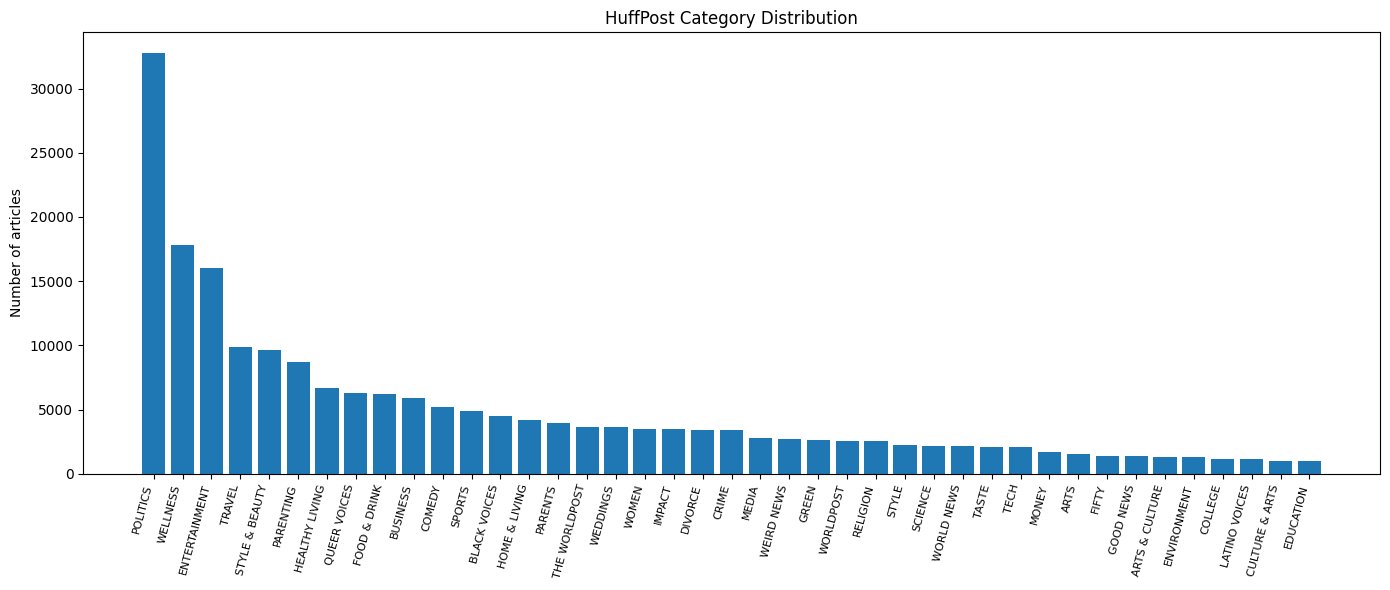


=== Text Length Summary ===
Median token length (50th percentile): 29
75th percentile: 36
90th percentile: 50
95th percentile: 57
Max token length: 246

Estimated truncation rates:
  max_text_length= 64:   1.60% of samples would be truncated
  max_text_length=128:   0.08% of samples would be truncated
  max_text_length=256:   0.00% of samples would be truncated
  max_text_length=300:   0.00% of samples would be truncated
  max_text_length=512:   0.00% of samples would be truncated


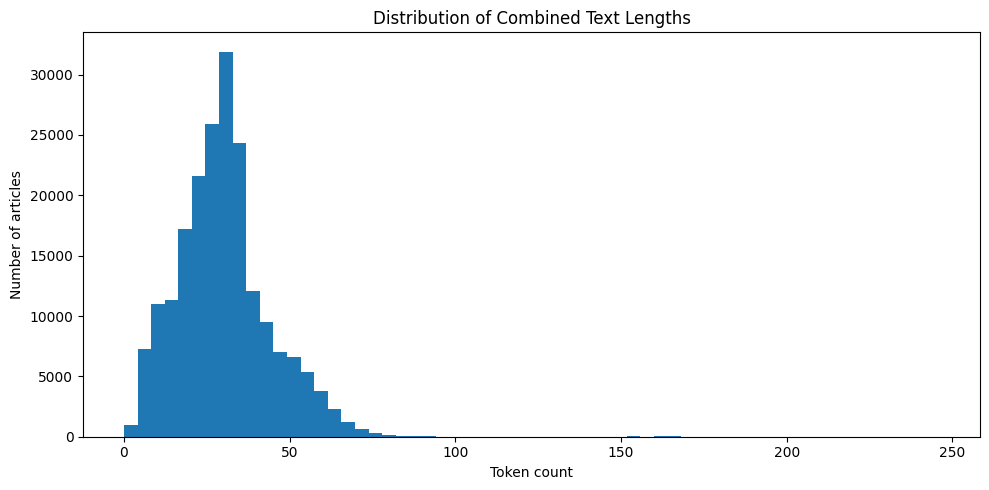


=== Missing / Low-Information Records ===
Empty headlines: 6 (0.00%)
Empty short descriptions: 19,712 (9.81%)
Very short combined texts (<= 3 tokens): 472 (0.23%)

=== Duplicate Checks ===
Duplicate headline rows: 1,509 (0.75%)
Duplicate combined-text rows: 488 (0.24%)

Example duplicate headlines:
  (5x) What To Watch On Amazon Prime That’s New This Week
  (5x) What To Watch On Hulu That’s New This Week
  (80x) The 20 Funniest Tweets From Women This Week
  (4x) Here Are The Movies Coming To Netflix This Week
  (2x) What A Year This Month Has Been

=== Ambiguous / Overlapping Category Examples ===

[POLITICS] vs [WORLD NEWS]
  POLITICS: Trump's Crackdown On Immigrant Parents Puts More Kids In An Already Strained System [SEP] Last month a Health and Human Services official re
  POLITICS: 'Trump's Son Should Be Concerned': FBI Obtained Wiretaps Of Putin Ally Who Met With Trump Jr. [SEP] The wiretaps feature conversations betwe
  WORLD NEWS: South Korean President Meets North Korea's Kim

In [11]:
# Your code here, add as many cells as you like. Provide organization and structure by appropriate comments, labels, and variable names. Explain what
# you are doing in case you come back to this in a year.
#In the following analysis, we quantify class imbalance, text-length variation, missing or duplicate entries, and potentially overlapping labels so we can make informed decisions about preprocessing, sequence length, evaluation metrics, and baseline modeling strategy.
# ============================================
# Problem 2 - Frame the Problem
# Diagnostic EDA for modeling decisions
# ============================================

# --------------------------------------------------
# 1) Build combined text field
# --------------------------------------------------
def make_text(ex):
    headline = (ex.get("headline") or "").strip()
    short_desc = (ex.get("short_description") or "").strip()
    if short_desc:
        text = f"{headline} [SEP] {short_desc}"
    else:
        text = headline
    return {"text": text}

huff_text = huff_all.map(make_text)

# --------------------------------------------------
# 2) Class distribution + imbalance summary
# --------------------------------------------------
cat_counts = Counter(huff_text["category"])
cats_sorted = sorted(cat_counts.items(), key=lambda x: x[1], reverse=True)
labels, counts = zip(*cats_sorted)

max_count = max(counts)
min_count = min(counts)
median_count = np.median(counts)

print("=== Class Balance Summary ===")
print(f"Total samples: {len(huff_text):,}")
print(f"Total classes: {len(cat_counts)}")
print(f"Most common class: {labels[0]} ({max_count:,})")
print(f"Least common class: {labels[-1]} ({min_count:,})")
print(f"Median class size: {median_count:.0f}")
print(f"Imbalance ratio (max / median): {max_count / median_count:.2f}x")

minority_classes = [cat for cat, c in cats_sorted if c < median_count]
print(f"Number of below-median classes: {len(minority_classes)}")
print("Example minority classes:", minority_classes[:10])

plt.figure(figsize=(14, 6))
plt.bar(range(len(labels)), counts)
plt.xticks(range(len(labels)), labels, rotation=75, ha="right", fontsize=8)
plt.ylabel("Number of articles")
plt.title("HuffPost Category Distribution")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3) Text length analysis
#    We use whitespace token counts as a simple proxy.
# --------------------------------------------------
token_lengths = np.array([len((t or "").split()) for t in huff_text["text"]])

p50, p75, p90, p95 = np.percentile(token_lengths, [50, 75, 90, 95])

print("\n=== Text Length Summary ===")
print(f"Median token length (50th percentile): {p50:.0f}")
print(f"75th percentile: {p75:.0f}")
print(f"90th percentile: {p90:.0f}")
print(f"95th percentile: {p95:.0f}")
print(f"Max token length: {token_lengths.max():.0f}")

candidate_lengths = [64, 128, 256, 300, 512]
print("\nEstimated truncation rates:")
for L in candidate_lengths:
    trunc_rate = np.mean(token_lengths > L) * 100
    print(f"  max_text_length={L:>3}: {trunc_rate:6.2f}% of samples would be truncated")

plt.figure(figsize=(10, 5))
plt.hist(token_lengths, bins=60)
plt.xlabel("Token count")
plt.ylabel("Number of articles")
plt.title("Distribution of Combined Text Lengths")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 4) Missing / low-information records
# --------------------------------------------------
empty_headline = sum(1 for x in huff_text["headline"] if not (x or "").strip())
empty_desc = sum(1 for x in huff_text["short_description"] if not (x or "").strip())
very_short_text = sum(1 for t in huff_text["text"] if len((t or "").split()) <= 3)

print("\n=== Missing / Low-Information Records ===")
print(f"Empty headlines: {empty_headline:,} ({100 * empty_headline / len(huff_text):.2f}%)")
print(f"Empty short descriptions: {empty_desc:,} ({100 * empty_desc / len(huff_text):.2f}%)")
print(f"Very short combined texts (<= 3 tokens): {very_short_text:,} ({100 * very_short_text / len(huff_text):.2f}%)")

# --------------------------------------------------
# 5) Duplicate checks
# --------------------------------------------------
headline_counts = Counter((x or "").strip() for x in huff_text["headline"])
text_counts = Counter((x or "").strip() for x in huff_text["text"])

dup_headline_rows = sum(c - 1 for c in headline_counts.values() if c > 1)
dup_text_rows = sum(c - 1 for c in text_counts.values() if c > 1)

print("\n=== Duplicate Checks ===")
print(f"Duplicate headline rows: {dup_headline_rows:,} ({100 * dup_headline_rows / len(huff_text):.2f}%)")
print(f"Duplicate combined-text rows: {dup_text_rows:,} ({100 * dup_text_rows / len(huff_text):.2f}%)")

# show a few duplicate headline examples
print("\nExample duplicate headlines:")
shown = 0
for headline, c in headline_counts.items():
    if c > 1 and headline:
        print(f"  ({c}x) {headline}")
        shown += 1
        if shown == 5:
            break

# --------------------------------------------------
# 6) Ambiguous / overlapping label examples
# --------------------------------------------------
ambiguous_pairs = [
    ("POLITICS", "WORLD NEWS"),
    ("WELLNESS", "HEALTHY LIVING"),
    ("PARENTS", "PARENTING"),
    ("WORLDPOST", "THE WORLDPOST"),
]

samples_by_cat = {}
for cat_a, cat_b in ambiguous_pairs:
    samples_by_cat[cat_a] = []
    samples_by_cat[cat_b] = []

for ex in huff_text:
    cat = ex["category"]
    if cat in samples_by_cat and len(samples_by_cat[cat]) < 2:
        samples_by_cat[cat].append(ex["text"])

print("\n=== Ambiguous / Overlapping Category Examples ===")
for cat_a, cat_b in ambiguous_pairs:
    print(f"\n[{cat_a}] vs [{cat_b}]")
    for s in samples_by_cat[cat_a]:
        print(f"  {cat_a}: {s[:140]}")
    for s in samples_by_cat[cat_b]:
        print(f"  {cat_b}: {s[:140]}")

# --------------------------------------------------
# 7) Compute/resource considerations
# --------------------------------------------------
recommended_max_len = int(p95)

print("\n=== Practical Modeling Plan ===")
print(f"Recommended initial max_text_length: ~{recommended_max_len} tokens (near 95th percentile)")
print("Suggested first imbalance strategy: class_weight")
print("Suggested split strategy: stratified train/validation/test with fixed seed")
print("Suggested primary metric: macro-F1")
print("Suggested secondary metrics: accuracy, per-class precision/recall, confusion matrix")
print("Suggested first baseline: TF-IDF + Logistic Regression")
print("Suggested next model: Embedding + LSTM or compact transformer model")


### Graded Questions (3 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **State the prediction task**  
   - Describe what your model will predict (the *label*).  
   - *Examples:*  
     - “Given a photo of food, predict which of 101 categories it belongs to.”  
     - “Given a news headline + summary, predict its topical category.”  

2.1. **Your answer here:**
Model will perform multi-class text classification. Given the combined text of a news article in the format headline [SEP] short_description, it will predict which one of the 41 HuffPost topic categories the article belongs to. In other words, the model’s task is to automatically assign each article to its most appropriate topical label, such as POLITICS, ENTERTAINMENT, SPORTS, WELLNESS, or PARENTING, based on the article’s text content.

2. **Define inputs and outputs**  
   - *Inputs:* what information the model receives (e.g., pixel data, tokenized text).  
   - *Outputs:* the categorical label the model will predict.  

2.2. **Your answer here:**
The input to the model will be the textual content of each news article, specifically the concatenated headline and short description combined into a single string using a [SEP] token. During preprocessing, this text will be converted into numerical representations such as token indices, TF-IDF vectors, or dense word embeddings, depending on the modeling approach. The output will be a single categorical label corresponding to one of the 41 news topic classes in the dataset. The model will typically produce a probability score for each category, and the category with the highest predicted probability will be selected as the final classification.



3. **Identify possible challenges**  
   - Imbalanced classes, noisy data, ambiguous labels, overlapping features, or missing data  
   - *Images:* variation in lighting, color, composition, or size.  
   - *Text:* class imbalance, duplicate stories, short or ambiguous headlines.  

2.3. **Your answer here:**
Several challenges may affect model performance. First, the dataset shows significant class imbalance, with categories such as POLITICS containing far more articles than smaller classes like EDUCATION, which may bias the model toward predicting dominant labels. Second, there is label ambiguity and topical overlap between certain categories, such as POLITICS and WORLD NEWS or WELLNESS and HEALTHY LIVING, which can make it difficult for the model to distinguish between similar topics. Third, some records contain empty short descriptions, meaning the model must rely only on the headline for those examples. Finally,  dataset contains duplicate or near-duplicate headlines, which could introduce data leakage or artificially inflate evaluation metrics if not handled carefully during dataset splitting.


4. **Propose how you will prepare or improve the data to address the challenges**  
   - *Images:* resizing, normalization, data augmentation (flips, rotations, brightness, color jitter).  
   - *Text:* tokenization, stop-word removal, TF-IDF, class balancing, embeddings (choose an embedding approach and specify its vector size).

2.4. **Your answer here:**
To prepare the data, we will first combine the headline and short description into a single text field using a [SEP] token. We will then apply tokenization and analyze text-length percentiles so we can choose a reasonable maximum sequence length and truncate only unusually long samples. As an initial baseline, we may use TF-IDF features to represent the text, since they are efficient and effective for multi-class text classification. For a neural approach, we plan to use an embedding layer with approximately 100 to 300 dimensions, which can then be passed into a model such as an LSTM. To address class imbalance, we will start with class weighting during training and consider oversampling minority classes if needed. We will also remove exact duplicate entries before splitting the dataset to reduce leakage risk, and we may drop or separately evaluate records with empty short descriptions to understand how much they affect model performance.


5. **Specify success metrics**  
   - Identify the metrics you plan to use to evaluate model performance—typically **accuracy** and/or **F1-score**, which are standard for classification tasks.  
   - Briefly explain **why** these metrics are appropriate for your dataset and goal. For instance, accuracy may suffice for well-balanced datasets, while F1-score better reflects performance when some classes are under-represented.
   - If your dataset is **imbalanced**, consider computing **per-class metrics** (e.g., precision, recall, or F1 for each label) or **macro-averaged** scores, which give equal weight to each class regardless of its size—ensuring that minority classes are evaluated fairly.
In some cases, weighted averages (which weight classes by their frequency) or **confusion matrices** can also provide useful insight.
> You haven't run any models yet, and we haven’t studied every possible metric, but you’re encouraged to ask your favorite generative AI tool which evaluation metrics might best fit your dataset!
   - Clearly state how you will interpret success—for example, “Our goal is to achieve at least 80% overall accuracy without large per-class disparities.”

2.5. **Your answer here:**
Our primary evaluation metric will be macro-averaged F1 score because the HuffPost dataset is imbalanced, and macro-F1 gives equal importance to each class rather than allowing large categories such as POLITICS to dominate the results. We will also report overall accuracy as a secondary metric because it is easy to interpret and provides a broad view of model performance, although it may be misleading on its own for this dataset. In addition, we plan to examine per-class precision, recall, and F1 scores, along with a confusion matrix, to understand which categories are most often confused and whether minority classes are being classified fairly. We will consider the project successful if the model achieves strong overall accuracy and macro-F1 without severe performance drops on under-represented classes, meaning that it performs well across the full set of categories rather than only on the largest ones.


### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

**AI Question: Your answer here:**
Generative AI tools were used primarily as a writing and brainstorming aid while preparing this milestone. They helped refine the wording of explanations, improve the organization of responses, and suggest possible preprocessing strategies, modeling approaches, and evaluation metrics appropriate for a multi-class text classification problem. However, all dataset loading, exploratory data analysis, interpretation of results, and final decisions regarding challenges and solution approaches were based on our own review of the dataset and notebook outputs. AI assistance was used to enhance clarity and structure, not to replace the actual analytical work.

---

## Appendix: A quick guide to Hugging Face Datasets

#### 1) What are they?

* A **table-like** dataset: rows = examples, columns = named fields (e.g., `"image"`, `"label"`, `"headline"`).
* Backed by **Apache Arrow** → fast, memory-efficient, lazy transforms.
* Two core objects:

  * `Dataset` — one table of rows/columns.
  * `DatasetDict` — a dict of splits, e.g. `{"train": Dataset, "val": Dataset, "test": Dataset}`.


#### 2) Load and inspect

```python
from datasets import load_dataset

# Food-101 (images)
food = load_dataset("food101", split="train+validation")  # both splits at once
len(food), food.column_names, food.features
# -> (≈101000, ['image','label'], {'label': ClassLabel(num_classes=101, names=[...])})

# Access by name (not by numeric column index!)
row0 = food[0]
img0, y0 = row0["image"], row0["label"]     # PIL image, int id
label_names = food.features["label"].names
label_names[y0]
```

For text (HuffPost JSON mirror):

```python
url = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff = load_dataset("json", data_files=url, split="train")
huff.column_names  # e.g. ['headline','short_description','category','authors','link','date']
```


#### 3) Common transforms

`Dataset`s are **immutable**: ops return a new dataset.

* **Map** (add/modify columns):

```python
def mk_text(ex):
    h = (ex.get("headline") or "").strip()
    s = (ex.get("short_description") or "").strip()
    return {"text": (h + " [SEP] " + s).strip()}

huff = huff.map(mk_text)  # adds 'text' column
```

* **Class-encode** labels (strings → integers with a vocabulary):

```python
from datasets.features import ClassLabel
if not isinstance(huff.features["category"], ClassLabel):
    huff = huff.class_encode_column("category")  # now ints with .names
```

* **Filter / select / rename / drop**:

```python
small = huff.select(range(5000))  # first 5k rows
huff = huff.remove_columns(["authors","link","date"])
huff = huff.rename_column("category", "label")
```


#### 4) Splitting & shuffling

```python
# Stratified 80/10/10 on Food-101 by 'label'
from datasets import DatasetDict
label_col = "label"

tmp = food.train_test_split(test_size=0.10, seed=42, stratify_by_column=label_col)
train_val = tmp["train"].train_test_split(test_size=1/9, seed=42, stratify_by_column=label_col)
ds = DatasetDict(train=train_val["train"], val=train_val["test"], test=tmp["test"])

len(ds["train"]), len(ds["val"]), len(ds["test"])
```

* `train_test_split` is **random by default** (reproducible with `seed=`).
* You typically **don’t need to pre-shuffle** datasets if your training dataloader already shuffles each epoch.


#### 5) Working with images

Use `with_transform` to apply on-the-fly resizing/augmentation and return tensors:

```python
import torchvision.transforms as T
from torch.utils.data import DataLoader
import torch, math, random

IM_SIZE = 224
train_tfms = T.Compose([T.RandomResizedCrop(IM_SIZE), T.RandomHorizontalFlip(), T.ToTensor()])
eval_tfms  = T.Compose([T.Resize(256), T.CenterCrop(IM_SIZE), T.ToTensor()])

def add_pixel_values(ex, tfms):  # ex['image'] -> ex['pixel_values']
    ex = dict(ex); ex["pixel_values"] = tfms(ex["image"]); return ex

train_t = ds["train"].with_transform(lambda ex: add_pixel_values(ex, train_tfms))
val_t   = ds["val"].with_transform(lambda ex: add_pixel_values(ex, eval_tfms))

def collate(batch):
    return {"pixel_values": torch.stack([b["pixel_values"] for b in batch]),
            "labels": torch.tensor([b["label"] for b in batch])}

train_loader = DataLoader(train_t, batch_size=64, shuffle=True,  collate_fn=collate)
val_loader   = DataLoader(val_t,   batch_size=64, shuffle=False, collate_fn=collate)
```

### 6) Working with Text

You can preprocess and tokenize text datasets using either a **transformer tokenizer** or a **linguistic pipeline like spaCy**, depending on your model type and goals.


#### Option A: Transformer Tokenizer (for fine-tuning models like BERT or DistilBERT)

Use a pretrained tokenizer with the Hugging Face `map` method to efficiently process your dataset in batches:

```python
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tok(batch["text"], truncation=True, padding="max_length", max_length=128)

tokenized = huff.map(
    tokenize,
    batched=True,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

This produces token IDs, attention masks, and other fields expected by transformer models.
Use this approach if your project involves fine-tuning pretrained language models.


#### Option B: spaCy Tokenization and Cleaning (for classical ML or custom preprocessing)

If you are **not using transformers**, or if you want to explore feature engineering (e.g., TF-IDF, word frequency, or embedding averages), you can preprocess text with **spaCy** instead.

```python
# !pip install spacy
# !python -m spacy download en_core_web_sm

import spacy
from datasets import load_dataset

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "textcat"])
STOP = spacy.lang.en.stop_words.STOP_WORDS

def spacy_clean(batch):
    docs = list(nlp.pipe(batch["text"], batch_size=1000))
    cleaned = []
    for doc in docs:
        tokens = [t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop]
        cleaned.append(" ".join(tokens))
    return {"text_clean": cleaned, "len_tokens": [len(c.split()) for c in cleaned]}

huff = huff.map(
    spacy_clean,
    batched=True,
    batch_size=1000,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

The resulting column `text_clean` can be used with:

* `TfidfVectorizer` (Scikit-learn)
* `TextVectorization` (Keras)
* or any other custom embedding method.

> 💡 **Tip:** spaCy is ideal for lightweight NLP pipelines or for models that rely on explicit preprocessing (lemmatization, stopword removal). Transformer tokenizers, by contrast, expect *raw text* and handle subword tokenization internally.



#### 7) Slicing, concatenating, saving

```python
# Slicing
head_1000 = food.select(range(1000))
tail_10pct = food.select(range(int(0.9*len(food)), len(food)))

# Concatenate splits/datasets
from datasets import concatenate_datasets
all_train = concatenate_datasets([ds["train"], ds["val"]])

# Save / reload
ds.save_to_disk("food101_splits")
from datasets import load_from_disk
ds2 = load_from_disk("food101_splits")
```


#### 8) Quick “gotchas”

* **Columns by name** (strings), not numeric indices.
* Avoid converting huge columns to `list(...)` unless necessary; prefer vectorized ops with `map`, `filter`, `select`.
* `PYTHONHASHSEED` must be set **before** the Python process starts to matter; use explicit `seed=` arguments for reproducibility.
* Datasets print **previews** (e.g., `Column([6, 6, 6, ...])` is just the first few values).


#### 9) A minimal checklist to follow

1. `load_dataset(...)` → confirm `column_names`, `features`.
2. Build any needed columns (`"text"`), and **class-encode** labels if strings.
3. Make a **stratified 80/10/10** split (`train_test_split` ×2).
4. Do **EDA**: class counts, sample printouts or image grids.
5. For training:

   * **images** → `with_transform` + DataLoader
   * **text** → tokenizer via `.map(...)` + trainer/model pipeline
6. Save your `DatasetDict` with `save_to_disk(...)` (optional for text but handy, **don't** use it for big image datasets).

